Starting propagation scan...


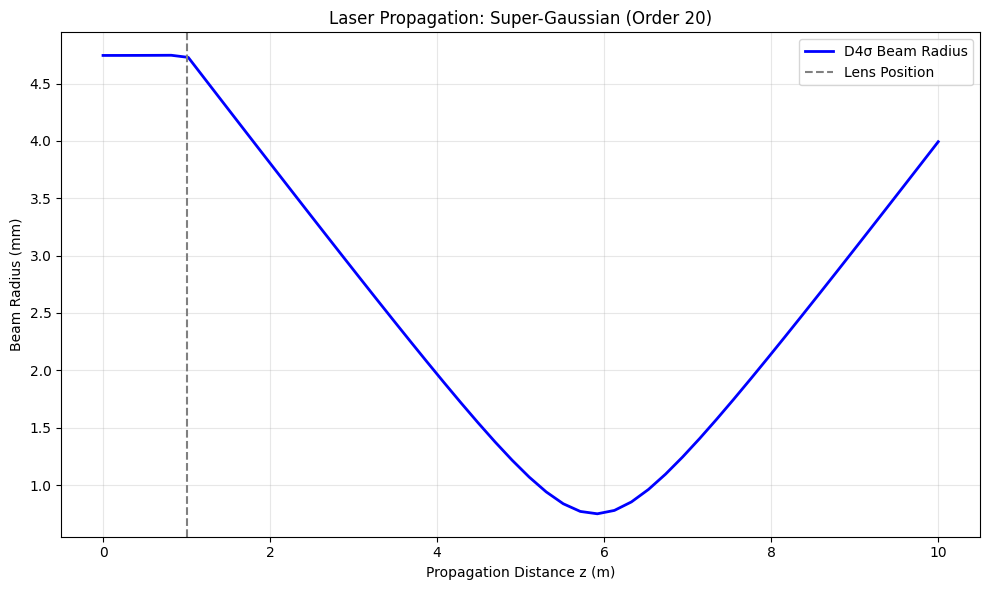

Focus found at z = 5.918 m
Beam waist (w0) = 749.61 um
Equivalent Rayleigh Range (zR) = 1.7653 m


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fft import fft2, ifft2, fftshift, ifftshift

def propagate_asm(Uin, x, y, wavelength, z):
    """Propagates a complex field Uin by distance z using Angular Spectrum Method."""
    if z == 0: return Uin
    
    nx, ny = Uin.shape
    dx = x[1] - x[0]
    dy = y[1] - y[0]
    
    # Frequency coordinates
    fx = fftshift(np.fft.fftfreq(nx, d=dx))
    fy = fftshift(np.fft.fftfreq(ny, d=dy))
    FX, FY = np.meshgrid(fx, fy)
    
    k = 2 * np.pi / wavelength
    
    # Transfer function for ASM
    # Using the exact Helmholtz propagator (evanescent waves filtered)
    argument = k**2 - (2 * np.pi * FX)**2 - (2 * np.pi * FY)**2
    H = np.exp(1j * np.sqrt(np.maximum(argument, 0)) * z)
    H[argument < 0] = 0 # Filter out evanescent waves
    
    # Propagation
    U_fft = fftshift(fft2(ifftshift(Uin)))
    U_out = fftshift(ifft2(ifftshift(U_fft * H)))
    return U_out

def get_d4sigma_radius(U, x, y):
    """Computes the D4sigma beam radius based on ISO 11146."""
    intensity = np.abs(U)**2
    total_power = np.sum(intensity)
    
    # Centroids
    x0 = np.sum(intensity * x) / total_power
    y0 = np.sum(intensity * y) / total_power
    
    # Second moments
    var_x = np.sum(intensity * (x - x0)**2) / total_power
    var_y = np.sum(intensity * (y - y0)**2) / total_power
    
    # D4sigma radius (average of x and y for near-circular beams)
    sigma = np.sqrt(var_x + var_y)
    return sigma * np.sqrt(2) # ISO 11146 defines d = 4*sigma, so w = 2*sigma

# --- Parameters ---
wavelength = 1000e-9      # 800 nm
f_lens = 5.0             # 5 meters
w_init = 0.005           # 10 mm initial beam radius
order = 20                # Super-Gaussian order (flat-top)
grid_size = 0.15         # 8 cm total simulation window
N = 1024                 # Grid points
z_steps = 50            # Number of steps along z-axis
z_max = 10.0             # Propagation end point
z_lens = 1.0             # Position of the lens

# Setup Grid
x_vec = np.linspace(-grid_size/2, grid_size/2, N)
y_vec = np.linspace(-grid_size/2, grid_size/2, N)
X, Y = np.meshgrid(x_vec, y_vec)
R = np.sqrt(X**2 + Y**2)
k = 2 * np.pi / wavelength

# 1. Define Input Field (Super-Gaussian)
U = np.exp(-(R / w_init)**order).astype(complex)

# 2. Propagation Loop (Z-Scan)
z_vals = np.linspace(0, z_max, z_steps)
beam_radii = []

print("Starting propagation scan...")
for z in z_vals:
    if z <= z_lens:
        # Propagation from source to lens
        U_current = propagate_asm(U, x_vec, y_vec, wavelength, z)
    else:
        # Propagate to lens, apply lens, then propagate further
        U_at_lens = propagate_asm(U, x_vec, y_vec, wavelength, z_lens)
        # Apply thin lens phase: exp(-i * k * r^2 / (2f))
        U_after_lens = U_at_lens * np.exp(-1j * k * (X**2 + Y**2) / (2 * f_lens))
        U_current = propagate_asm(U_after_lens, x_vec, y_vec, wavelength, z - z_lens)
    
    beam_radii.append(get_d4sigma_radius(U_current, X, Y))

# --- Analysis ---
z_vals = np.array(z_vals)
beam_radii = np.array(beam_radii)

# Find waist after the lens
mask_after_lens = z_vals > z_lens
z_after = z_vals[mask_after_lens]
w_after = beam_radii[mask_after_lens]

idx_focus = np.argmin(w_after)
z_focus = z_after[idx_focus]
w0 = w_after[idx_focus]
z_R = (np.pi * w0**2) / wavelength # Gaussian-equivalent Rayleigh range

# --- Plotting ---
plt.figure(figsize=(10, 6))
plt.plot(z_vals, beam_radii * 1e3, 'b-', lw=2, label='D4σ Beam Radius')
plt.axvline(z_lens, color='gray', linestyle='--', label='Lens Position')


# Annotations

plt.title(f"Laser Propagation: Super-Gaussian (Order {order})")
plt.xlabel("Propagation Distance z (m)")
plt.ylabel("Beam Radius (mm)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Focus found at z = {z_focus:.3f} m")
print(f"Beam waist (w0) = {w0*1e6:.2f} um")
print(f"Equivalent Rayleigh Range (zR) = {z_R:.4f} m")

In [1]:
pip install scipy


   ---------------------------------------- 0.0/39.4 MB ? eta -:--:--
   ------ --------------------------------- 6.8/39.4 MB 34.3 MB/s eta 0:00:01
   ----------------------- ---------------- 23.1/39.4 MB 57.6 MB/s eta 0:00:01
   ---------------------------------------  39.3/39.4 MB 66.2 MB/s eta 0:00:01
   ---------------------------------------- 39.4/39.4 MB 62.2 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip
